<a href="https://colab.research.google.com/github/3olena3/yoga-pose-classification/blob/main/yoga_pose_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import sys
import tensorflow as tf
from sklearn.metrics import f1_score, classification_report
import numpy as np

print(f"Версія Python: {sys.version}")
print(f"TensorFlow версія: {tf.__version__}")

gpu_status = tf.test.is_gpu_available()
print(f"Відеокарта підключена: {gpu_status}")

Версія Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow версія: 2.20.0
Відеокарта підключена: True


In [22]:
import zipfile
import os

with zipfile.ZipFile('yoga_dataset', 'r') as zip_ref:
    zip_ref.extractall('yoga_dataset')

print("Файли розпаковано. Список папок (класів поз):")
print(os.listdir('yoga_dataset'))

IsADirectoryError: [Errno 21] Is a directory: 'yoga_dataset'

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2 )

train_data = datagen.flow_from_directory(
    'yoga_dataset',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    'yoga_dataset',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 1745 images belonging to 9 classes.
Found 432 images belonging to 9 classes.


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),

    layers.Dense(512, activation='relu'),

    layers.Dense(9, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,038,281 (72.63 MB)

 Trainable params: 19,038,281 (72.63 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(
    train_data,
    steps_per_epoch=train_data.samples // 32,
    epochs=10,
    validation_data=val_data,
    validation_steps=val_data.samples // 32
)

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.2206 - loss: 2.9577

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 4 bytes but only got 2. 
  warnings.warn(str(msg))


54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 294ms/step - accuracy: 0.2656 - loss: 2.2377 - val_accuracy: 0.3438 - val_loss: 1.7605
Epoch 2/10
 1/54 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.2812 - loss: 1.8777

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.2812 - loss: 1.8777 - val_accuracy: 0.3582 - val_loss: 1.7408
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - accuracy: 0.4524 - loss: 1.5960 - val_accuracy: 0.4615 - val_loss: 1.4471
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.3750 - loss: 1.8524 - val_accuracy: 0.5072 - val_loss: 1.3963
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 206ms/step - accuracy: 0.6077 - loss: 1.1815 - val_accuracy: 0.6298 - val_loss: 1.0156
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.6562 - loss: 1.1778 - val_accuracy: 0.6370 - val_loss: 0.9954
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 194ms/step - accuracy: 0.7572 - loss: 0.7426 - val_accuracy: 0.7668 - val_loss: 0.7958
Epoch 8/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.8125 - loss: 0.6085 - val_accuracy: 0.7428 - val_loss: 0.8310
Epoch 9/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - accuracy: 0.8494 - loss: 0.4535 - val_accuracy: 0.8389 - val_

Saving images (1).jpg to images (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 788ms/step


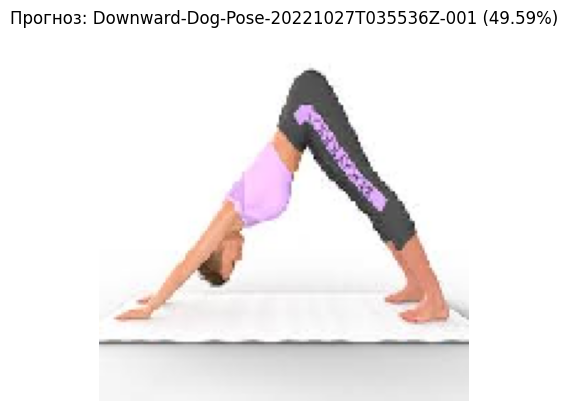

Файл images (1).jpg розпізнано як Downward-Dog-Pose-20221027T035536Z-001 з імовірністю 49.6%


In [27]:

from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

uploaded = files.upload()

for fn in uploaded.keys():
    img = image.load_img(fn, target_size=(150, 150))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x /= 255.0

    predictions = model.predict(x)

    labels = {v: k for k, v in train_data.class_indices.items()}
    predicted_class_idx = np.argmax(predictions)
    predicted_label = labels[predicted_class_idx]
    confidence = predictions[0][predicted_class_idx] * 100


    plt.imshow(img)
    plt.title(f"Прогноз: {predicted_label} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"Файл {fn} розпізнано як {predicted_label} з імовірністю {confidence:.1f}%")